#### In this notebook, we focus on visualizing the key business insights derived from the analytical dataset. The objective is to convert the analytical results into clear, informative, and easy-to-interpret visualizations that enable stakeholders to quickly understand sales patterns, product performance, and overall business trends.

### Importing Libraries

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

### Loading Dataset from SQLite Database

In [219]:
# ==============================
# Connect to SQLite Database
# ==============================
engine = create_engine('sqlite:///pizza_sales_analysis.db')


# ==============================
# Load Data from SQL Table
# ==============================
df = pd.read_sql_query('SELECT * FROM pizza', engine)

### Preview & Validate Loaded Dataset

In [218]:
# ==============================
# Dataset Structure Information
# ==============================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    48620 non-null  int64  
 1   name        48620 non-null  object 
 2   category    48620 non-null  object 
 3   size        48620 non-null  object 
 4   price       48620 non-null  float64
 5   quantity    48620 non-null  int64  
 6   revenue     48620 non-null  float64
 7   month_name  48620 non-null  object 
 8   hour        48620 non-null  int64  
 9   weekday     48620 non-null  object 
 10  day_type    48620 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 4.1+ MB


In [217]:
# ==============================
# Statistical Summary of Numeric Columns
# ==============================
stats_summary = df.describe()
stats_summary

,order_id,price,quantity,revenue,hour
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,10701.479761,16.494132,1.019622,16.821474,15.911806
std,6180.119770,3.621789,0.143077,4.437398,3.149836
min,1.000000,9.750000,1.000000,9.750000,9.000000
25%,5337.000000,12.750000,1.000000,12.750000,13.000000
50%,10682.500000,16.500000,1.000000,16.500000,16.000000
75%,16100.000000,20.250000,1.000000,20.500000,18.000000
max,21350.000000,35.950000,4.000000,83.000000,23.000000


In [216]:
# ==============================
# Checking Missing Values in Each Column
# ==============================
missing_values = df.isnull().sum()
missing_values

order_id      0
name          0
category      0
size          0
price         0
quantity      0
revenue       0
month_name    0
hour          0
weekday       0
day_type      0
dtype: int64

In [215]:
# ==============================
# Explore Unique Values in Each Column
# ==============================
for col in df.columns:
    print('\n' + '*' * 50, col, '*' * 50)
    print(df[col].unique())


************************************************** order_id **************************************************
[    1     2     3 ... 21348 21349 21350]

************************************************** name **************************************************
['The Hawaiian Pizza' 'The Classic Deluxe Pizza' 'The Five Cheese Pizza'
 'The Italian Supreme Pizza' 'The Mexicana Pizza' 'The Thai Chicken Pizza'
 'The Prosciutto and Arugula Pizza' 'The Barbecue Chicken Pizza'
 'The Greek Pizza' 'The Spinach Supreme Pizza' 'The Green Garden Pizza'
 'The Italian Capocollo Pizza' 'The Spicy Italian Pizza'
 'The Spinach Pesto Pizza' 'The Vegetables + Vegetables Pizza'
 'The Southwest Chicken Pizza' 'The California Chicken Pizza'
 'The Pepperoni Pizza' 'The Chicken Pesto Pizza' 'The Big Meat Pizza'
 'The Soppressata Pizza' 'The Four Cheese Pizza' 'The Napolitana Pizza'
 'The Calabrese Pizza' 'The Italian Vegetables Pizza'
 'The Mediterranean Pizza' 'The Pepper Salami Pizza'
 'The Spinach and Feta

In [214]:
# ==============================
# Check for Duplicate Rows
# ==============================
duplicates = df[df.duplicated()]
duplicates


,order_id,name,category,size,price,quantity,revenue,month_name,hour,weekday,day_type


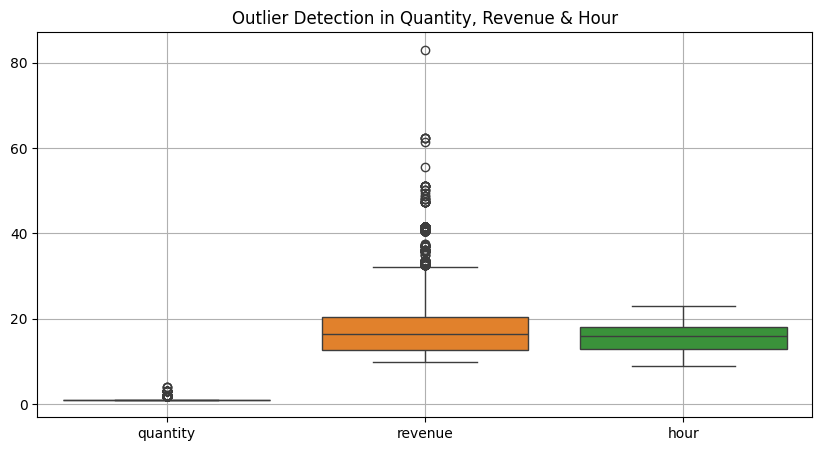

In [213]:
# ==============================
# Detecting Outliers in Numeric Features
# ==============================
cols = ['quantity', 'revenue', 'hour']

plt.figure(figsize=(10, 5))

sns.boxplot(data=df[cols])

plt.title("Outlier Detection in Quantity, Revenue & Hour")
plt.grid(True)
plt.show()

#### After analyzing the boxplot of quantity, revenue, and hour, no critical data quality issues were identified. The dataset appears clean and consistent, with only a few natural high-value observations in the revenue column, which represent peak sales rather than errors.
#### These higher revenue points indicate that some pizza orders generate significantly more revenue than average, suggesting the presence of premium or highly popular pizzas that contribute strongly to overall sales performance.

### Overall Sales Performance

In [212]:
# ==============================
# Total Revenue of All Orders
# ==============================
total_revenue = round(df['revenue'].sum(), 2)
total_revenue

817860.05

In [211]:
# ==============================
# Total Unique Orders
# ==============================
total_unique_orders = df['order_id'].nunique()
total_unique_orders

21350

### Key Business Questions

#### Which pizza sells the most by quantity?


In [210]:
# ==============================
# Top 10 Pizzas by Quantity Sold
# ==============================
pizza_performance_qt = (
    df.groupby('name')['quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
pizza_performance_qt

name
The Classic Deluxe Pizza        2453
The Barbecue Chicken Pizza      2432
The Hawaiian Pizza              2422
The Pepperoni Pizza             2418
The Thai Chicken Pizza          2371
The California Chicken Pizza    2370
The Sicilian Pizza              1938
The Spicy Italian Pizza         1924
The Southwest Chicken Pizza     1917
The Big Meat Pizza              1914
Name: quantity, dtype: int64

#### Which pizza generates most revenue?

In [209]:
# ==============================
# Top 10 Pizzas by Revenue
# ==============================
pizza_performance_rev = (
    df.groupby('name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
pizza_performance_rev

name
The Thai Chicken Pizza          43434.25
The Barbecue Chicken Pizza      42768.00
The California Chicken Pizza    41409.50
The Classic Deluxe Pizza        38180.50
The Spicy Italian Pizza         34831.25
The Southwest Chicken Pizza     34705.75
The Italian Supreme Pizza       33476.75
The Hawaiian Pizza              32273.25
The Four Cheese Pizza           32265.70
The Sicilian Pizza              30940.50
Name: revenue, dtype: float64

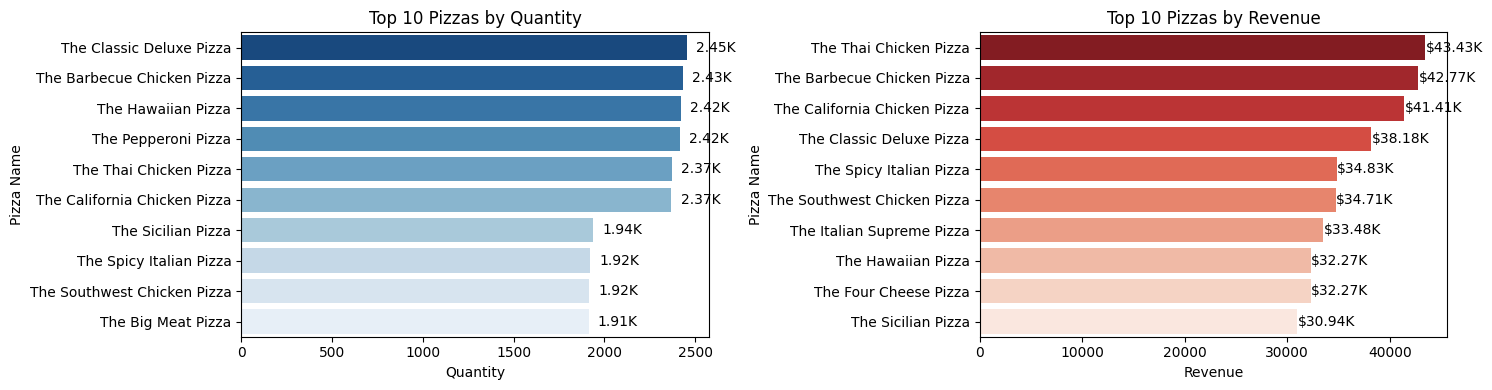

In [208]:
# ==============================
# Figure Setup
# ==============================
plt.figure(figsize=(15, 4))


# ==============================
# 1. Top Pizzas by Quantity
# ==============================
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=pizza_performance_qt.index,
    x=pizza_performance_qt.values,
    palette='Blues_r'
)

# Add data labels
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width() / 1000:.2f}K',
        va='center'
    )

ax1.set_xlabel('Quantity')
ax1.set_ylabel('Pizza Name')
ax1.set_title('Top 10 Pizzas by Quantity')


# ==============================
# 2. Top Pizzas by Revenue
# ==============================
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=pizza_performance_rev.index,
    x=pizza_performance_rev.values,
    palette='Reds_r'
)

# Add data labels
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width() / 1000:.2f}K',
        va='center'
    )

ax2.set_xlabel('Revenue')
ax2.set_ylabel('Pizza Name')
ax2.set_title('Top 10 Pizzas by Revenue')


# ==============================
# Layout Adjustment
# ==============================
plt.tight_layout()
plt.show()

#### Average Order Quantity by Pizza Size

In [206]:
# ==============================
# Average Quantity by Pizza Size
# ==============================
avg_order_qty_by_size = (
    df.groupby('size')['quantity']
      .mean()
      .sort_values(ascending=False)
)
avg_order_qty_by_size

size
L      1.023211
S      1.018816
M      1.016250
XL     1.014706
XXL    1.000000
Name: quantity, dtype: float64

#### Revenue Distribution by Pizza Size

In [207]:
# ==============================
# Revenue by Pizza Size
# ==============================
revenue_by_size = (
    df.groupby('size')['revenue']
      .sum()
      .sort_values(ascending=False)
)
revenue_by_size

size
L      375318.70
M      249382.25
S      178076.50
XL      14076.00
XXL      1006.60
Name: revenue, dtype: float64

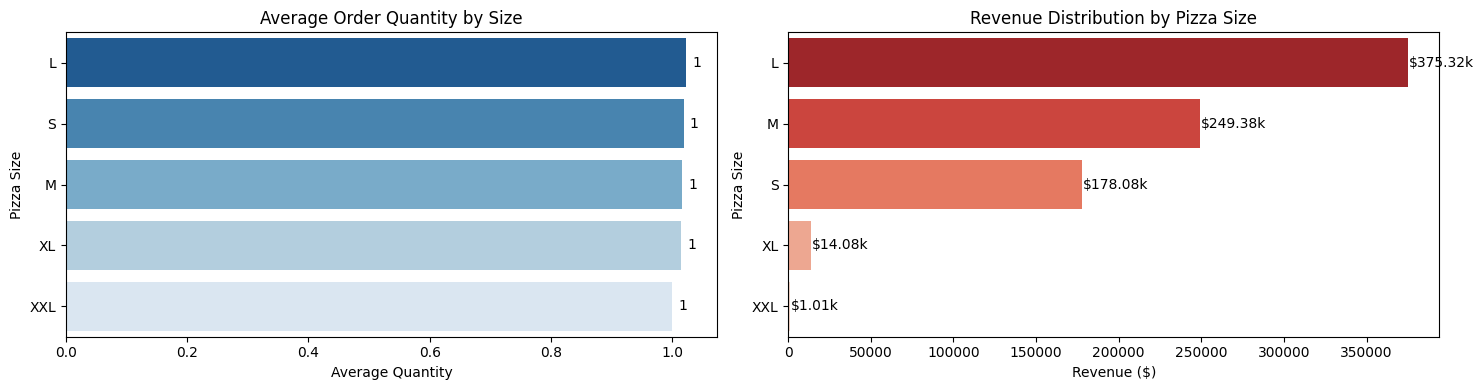

In [204]:
# ==============================
# Figure Setup
# ==============================
plt.figure(figsize=(15, 4))


# ==============================
# 1. Average Quantity by Pizza Size
# ==============================
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=avg_order_qty_by_size.index,
    x=avg_order_qty_by_size.values,
    palette='Blues_r'
)

# Add data labels
for bar in ax1.patches:
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    ax1.text(
        x + 0.01,
        y,
        f'{int(x):,}',
        va='center'
    )

plt.xlabel('Average Quantity')
plt.ylabel('Pizza Size')
plt.title('Average Order Quantity by Size')


# ==============================
# 2. Revenue by Pizza Size
# ==============================
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=revenue_by_size.index,
    x=revenue_by_size.values,
    palette='Reds_r'
)

# Add data labels
for bar in ax2.patches:
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    ax2.text(
        x + 500,
        y,
        f'${x/1000:.2f}k',
        va='center'
    )

plt.xlabel('Revenue ($)')
plt.ylabel('Pizza Size')
plt.title('Revenue Distribution by Pizza Size')


# ==============================
# Layout Adjustment
# ==============================
plt.tight_layout()
plt.show()

#### Which category sells most?


In [221]:
# ==============================
# Category-wise Total Orders
# ==============================
top_sales_category = (
    df.groupby('category')['order_id']
      .count()
      .sort_values(ascending=False)
)
top_sales_category

category
Classic    14579
Supreme    11777
Veggie     11449
Chicken    10815
Name: order_id, dtype: int64

#### Which category generates highest revenue?

In [222]:
# ==============================
# Category-wise Revenue Contribution
# ==============================
top_revenue_category = (
    df.groupby('category')['revenue']
      .sum()
      .sort_values(ascending=False)
      
)
top_revenue_category

category
Classic    220053.10
Supreme    208197.00
Chicken    195919.50
Veggie     193690.45
Name: revenue, dtype: float64

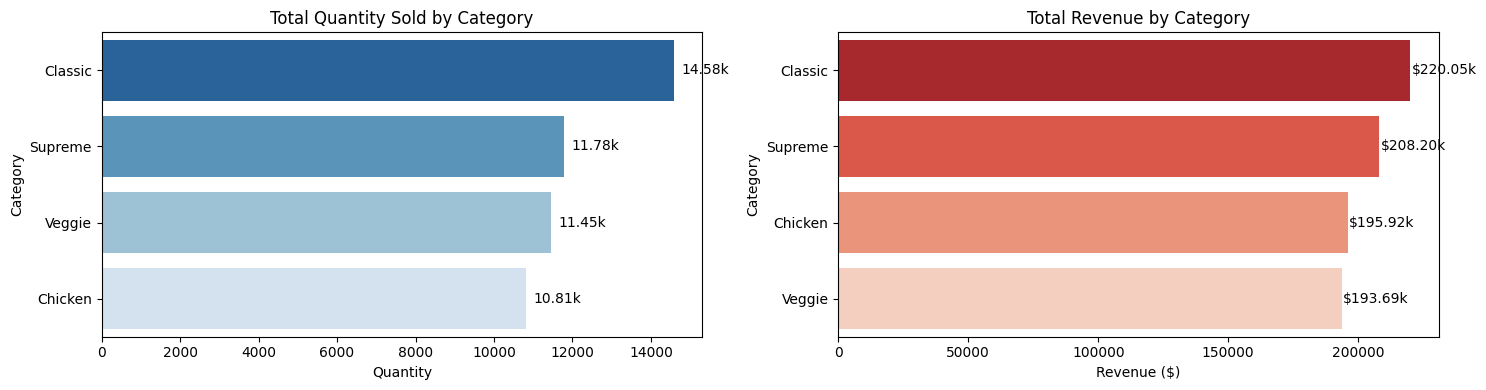

In [203]:
# ==============================
# Figure Setup
# ==============================
plt.figure(figsize=(15, 4))


# ==============================
# 1. Quantity Sold by Category
# ==============================
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_sales_category.index,
    x=top_sales_category.values,
    palette='Blues_r'
)

# Add data labels
for bar in ax1.patches:
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    ax1.text(
        x + 200,
        y,
        f'{x/1000:.2f}k',
        va='center'
    )

plt.title("Total Quantity Sold by Category")
plt.xlabel("Quantity")
plt.ylabel("Category")


# ==============================
# 2. Revenue by Category
# ==============================
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_revenue_category.index,
    x=top_revenue_category.values,
    palette='Reds_r'
)

# Add data labels
for bar in ax2.patches:
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    ax2.text(
        x + 500,
        y,
        f'${x/1000:.2f}k',
        va='center'
    )

plt.title("Total Revenue by Category")
plt.xlabel("Revenue ($)")
plt.ylabel("Category")


# ==============================
# Layout Adjustment
# ==============================
plt.tight_layout()
plt.show()

#### Creating Pizza Performance Summary (Orders & Revenue)

In [185]:
# ==============================
# Pizza-wise Performance Metrics
# ==============================
performance = (
    df.groupby('name')
      .agg(
          orders=('order_id', 'nunique'),  # Unique orders per pizza
          revenue=('revenue', 'sum')       # Total revenue per pizza
      )
      .reset_index()
)

,name,orders,revenue
0,The Barbecue Chicken Pizza,2273,42768.00
1,The Big Meat Pizza,1811,22968.00
2,The Brie Carre Pizza,480,11588.50
3,The Calabrese Pizza,918,15934.25
4,The California Chicken Pizza,2197,41409.50
5,The Chicken Alfredo Pizza,967,16900.25
6,The Chicken Pesto Pizza,938,16701.75
7,The Classic Deluxe Pizza,2329,38180.50
8,The Five Cheese Pizza,1359,26066.50
9,The Four Cheese Pizza,1809,32265.70


In [223]:
# ==============================
# Define Performance Thresholds using Quantiles
# ==============================

# Top 25% performers (high demand / high revenue threshold)
high_orders = performance['orders'].quantile(0.75)

# Bottom 15% performers (low demand threshold)
low_orders = performance['orders'].quantile(0.15)

# Bottom 15% revenue threshold (low revenue products)
low_revenue = performance['revenue'].quantile(0.15)

# Top 25% revenue performers
high_revenue = performance['revenue'].quantile(0.75)


In [225]:
# ==============================
# Filter Underperforming Pizzas
# (Low Orders AND Low Revenue)
# ==============================
target = performance[
    (performance['orders'] <= low_orders) &
    (performance['revenue'] <= low_revenue)
]
target

,name,orders,revenue
2,The Brie Carre Pizza,480,11588.50
16,The Mediterranean Pizza,912,15360.50
28,The Spinach Supreme Pizza,918,15277.75


In [226]:
# ==============================
# Filter Acceptable / High Performing Pizzas
# (Above Minimum Order & Revenue Thresholds)
# ==============================
pizza_performance = performance[
    (performance['orders'] >= low_orders) &
    (performance['revenue'] >= low_revenue)
]
pizza_performance

,name,orders,revenue
0,The Barbecue Chicken Pizza,2273,42768.00
1,The Big Meat Pizza,1811,22968.00
4,The California Chicken Pizza,2197,41409.50
5,The Chicken Alfredo Pizza,967,16900.25
7,The Classic Deluxe Pizza,2329,38180.50
8,The Five Cheese Pizza,1359,26066.50
9,The Four Cheese Pizza,1809,32265.70
10,The Greek Pizza,1361,28454.10
12,The Hawaiian Pizza,2280,32273.25
13,The Italian Capocollo Pizza,1380,25094.00


In [227]:
# ==============================
# Remove Extreme Revenue Outliers
# (Filter pizzas with very high revenue values)
# ==============================
pizza_performance = pizza_performance[
    pizza_performance['revenue'] < 35000
]

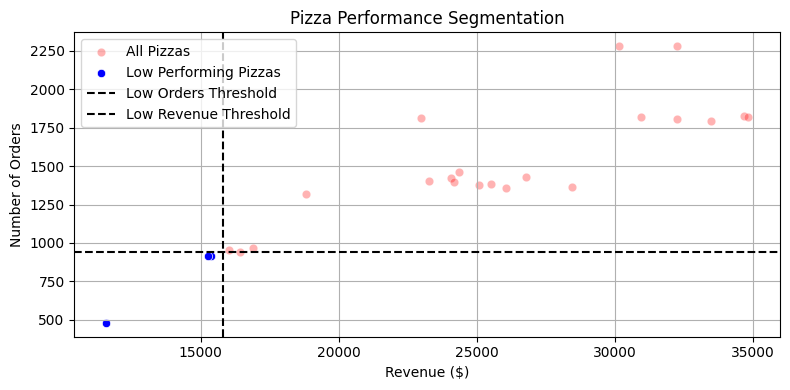

In [228]:
# ==============================
# Create Figure
# ==============================
plt.figure(figsize=(8, 4))


# ==============================
# All Pizzas (Background Distribution)
# ==============================
sns.scatterplot(
    data=pizza_performance,
    x='revenue',
    y='orders',
    color='red',
    label='All Pizzas',
    alpha=0.3
)


# ==============================
# Low Performing Pizzas (Target Group)
# ==============================
sns.scatterplot(
    data=target,
    x='revenue',
    y='orders',
    color='blue',
    label='Low Performing Pizzas'
)


# ==============================
# Threshold Reference Lines
# ==============================
plt.axhline(
    low_orders,
    linestyle='--',
    color='black',
    label='Low Orders Threshold'
)

plt.axvline(
    low_revenue,
    linestyle='--',
    color='black',
    label='Low Revenue Threshold'
)


# ==============================
# Labels & Styling
# ==============================
plt.xlabel('Revenue ($)')
plt.ylabel('Number of Orders')
plt.title('Pizza Performance Segmentation')
plt.grid(True)
plt.legend()


plt.tight_layout()
plt.show()

#### Hourly Revenue Performance Analysis

In [229]:
# ==============================
# Hour-wise Revenue Aggregation
# ==============================
hour_performance = (
    df.groupby('hour')
      .agg({'revenue': 'sum'})
      .reset_index()
)
hour_performance

,hour,revenue
0,9,83.00
1,10,303.65
2,11,44935.80
3,12,111877.90
4,13,106065.70
5,14,59201.40
6,15,52992.30
7,16,70055.40
8,17,86237.45
9,18,89296.85


#### Monthly Revenue Performance Analysis

In [231]:
# ==============================
# Month-wise Revenue Aggregation
# ==============================
month_performance = (
    df.groupby('month_name')
      .agg({'revenue': 'sum'})
      .reset_index()
)
month_performance

,month_name,revenue
0,April,68736.80
1,August,68278.25
2,December,64701.15
3,February,65159.60
4,January,69793.30
5,July,72557.90
6,June,68230.20
7,March,70397.10
8,May,71402.75
9,November,70395.35


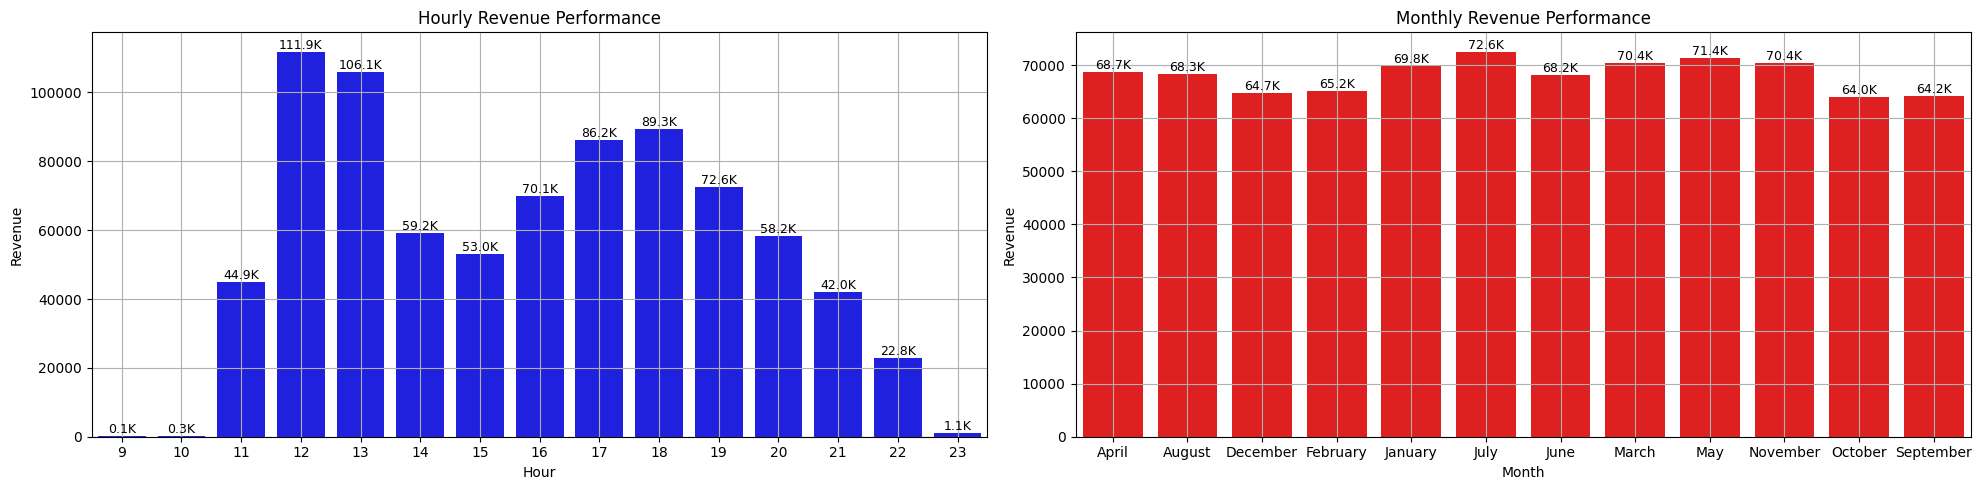

In [200]:
plt.figure(figsize=(20, 5))

# =========================
# 1. Hourly Revenue Plot
# =========================
plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    data=hour_performance,
    x='hour',
    y='revenue',
    color='blue'
)

# Add labels on bars
for bar in ax1.patches:
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = bar.get_height()
    
    label = f'{y_pos/1000:.1f}K'
    
    ax1.text(
        x_pos,
        y_pos,
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )

ax1.set_title("Hourly Revenue Performance")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Revenue")
ax1.grid(True)


# =========================
# 2. Monthly Revenue Plot
# =========================
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    data=month_performance,
    x='month_name',
    y='revenue',
    color='red'
)

# Add labels on bars
for bar in ax2.patches:
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = bar.get_height()
    
    label = f'{y_pos/1000:.1f}K'
    
    ax2.text(
        x_pos,
        y_pos,
        label,
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2.set_title("Monthly Revenue Performance")
ax2.set_xlabel("Month")
ax2.set_ylabel("Revenue")
ax2.grid(True)


plt.tight_layout()
plt.show()

#### Weekend vs Weekday Revenue Distribution Analysis

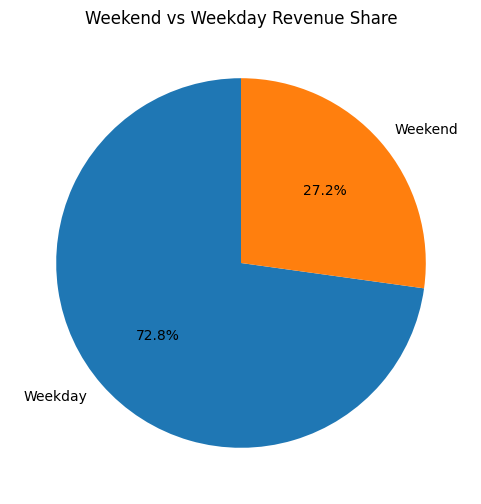

In [201]:
# ==============================
# Create Day Type (Weekend/Weekday)
# ==============================
df['day_type'] = df['weekday'].isin(['Saturday', 'Sunday']) \
                    .map({True: 'Weekend', False: 'Weekday'})


# ==============================
# Revenue Aggregation by Day Type
# ==============================
rev = df.groupby('day_type')['revenue'].sum()


# ==============================
# Pie Chart: Revenue Share
# ==============================
plt.figure(figsize=(6, 6))

plt.pie(
    rev.values,
    labels=rev.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Weekend vs Weekday Revenue Share")
plt.show()

### Strategic Revenue & Operational Insights
##### The Profitability Gap: There is a clear distinction between popularity and profitability. While The Classic Deluxe is your highest-volume mover, The Thai Chicken Pizza generates the most total revenue. This indicates that your premium-priced specialty pizzas are highly effective at driving the bottom line, even with fewer sales.

##### Size-Driven Revenue: The Large (L) pizza is your most critical financial asset, contributing more to revenue than all other sizes combined. Because the average order quantity is consistently 1.0 across all sizes, your revenue growth is tied entirely to the size of the pizza sold rather than the number of pizzas per order.

##### Core Category Strength: The Classic category is the undisputed backbone of your operations, leading in both total units sold and total revenue. It provides a level of market stability that allows you to experiment with more niche categories like Veggie or Chicken.

##### Peak Demand Windows: Your operation is heavily localized around a lunchtime peak at 12:00 PM, which generates significantly more revenue than the dinner rush. This suggests your primary customer base is likely the weekday workforce.

##### Underutilized Capacity: Despite being a 7-day operation, 72.8% of your revenue is concentrated on weekdays. Additionally, there is a sharp revenue "slump" between 2:00 PM and 4:00 PM, identifying a significant period where kitchen capacity and labor are underused.

##### Menu Inefficiencies: Your performance segmentation identifies specific low-performing pizzas that fail to cross the 1,000-order and $15k revenue thresholds. these items occupy valuable menu space and inventory costs without providing a meaningful return on investment.